# TP Ciencia de Datos 2026 — Scoring Académico
## Diseño, construcción y validación de un scoring de riesgo académico

**Dataset**: `Student exam score - 7 de mayo.csv` (200 estudiantes, 6 variables).

**Producto final**: scoring de **riesgo académico** de 0 a 100 — cuanto más alto, mayor riesgo de bajo desempeño en el examen final.

El trabajo construye dos versiones del score (basado en reglas y basado en modelo), las compara y propone niveles de interpretación con acciones asociadas.

## 1. Definición del problema

| Pregunta | Respuesta |
|---|---|
| **¿Qué decisión apoya el score?** | Detectar **antes del examen final** qué estudiantes tienen mayor probabilidad de bajo desempeño, para que la cátedra pueda intervenir (tutorías, recuperatorios, seguimiento). |
| **Unidad de análisis** | Un estudiante (1 fila = 1 estudiante = 1 score). |
| **¿Qué significa el score?** | **Riesgo de bajo desempeño académico** en el examen. |
| **¿Score alto = bueno o malo?** | Score alto = **negativo** (mayor riesgo). Convención coherente con scoring crediticio de riesgo. |
| **¿Quién lo usa?** | Tutores, coordinador académico y docente del curso. |
| **Momento de uso** | Al inicio o mitad del cuatrimestre, **antes** del examen final. Por eso `exam_score` **no puede entrar como variable predictora** (sería data leakage: la decisión la tomamos antes de conocerla). |

**Diferencia entre scoring, clasificación y predicción**:
- **Predicción**: estima el valor de `exam_score` (regresión).
- **Clasificación**: asigna 0 o 1 (¿desaprobará o no?).
- **Scoring**: ordena a los estudiantes en una escala continua (0 a 100) para priorizar intervenciones. Puede derivarse de un modelo de clasificación reescalando la probabilidad.

## 2. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

## 3. Carga del dataset

In [2]:
df = pd.read_csv('Student exam score - 7 de mayo.csv')
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.00,8.80,72.10,45,30.20
1,S002,1.30,8.60,60.70,55,25.00
2,S003,4.00,8.20,73.70,86,35.80
3,S004,3.50,4.80,95.10,66,34.00
4,S005,9.10,6.40,89.80,71,40.30


## 4. Exploración inicial

In [3]:
print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores faltantes por columna:')
print(df.isna().sum())
print('\nDuplicados de student_id:', df['student_id'].duplicated().sum())
print('Filas duplicadas completas:', df.duplicated().sum())

Dimensiones: (200, 6)

Tipos de datos:
student_id                str
hours_studied         float64
sleep_hours           float64
attendance_percent    float64
previous_scores         int64
exam_score            float64
dtype: object

Valores faltantes por columna:
student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

Duplicados de student_id: 0
Filas duplicadas completas: 0


In [4]:
df.describe().round(2)

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.00,200.00,200.00,200.00,200.00
mean,6.33,6.62,74.83,66.80,33.96
std,3.23,1.50,14.25,15.66,6.79
min,1.00,4.00,50.30,40.00,17.10
25%,3.50,5.30,62.20,54.00,29.50
50%,6.15,6.70,75.25,67.50,34.05
75%,9.00,8.02,87.43,80.00,38.75
max,12.00,9.00,100.00,95.00,51.30


### Lectura de la exploración

- **200 estudiantes**, sin nulos ni duplicados → no requiere imputación.
- `exam_score` va de **17.1 a 51.3** (no es un 0-100 clásico; el examen estaba en otra escala). Por eso **no podemos usar el umbral de 60 del PDF**: dejaría al 100% como riesgo.
- `previous_scores` sí está en escala 40-95, parece un promedio académico previo en escala 0-100.
- `hours_studied` 1-12, `sleep_hours` 4-9, `attendance_percent` 50-100. Rangos plausibles, sin valores físicamente imposibles.

### Detección de outliers (regla IQR)

In [5]:
def contar_outliers_iqr(serie: pd.Series) -> int:
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((serie < q1 - 1.5*iqr) | (serie > q3 + 1.5*iqr)).sum()

numericas = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores', 'exam_score']
outliers = {col: contar_outliers_iqr(df[col]) for col in numericas}
pd.Series(outliers, name='outliers_iqr').to_frame()

,outliers_iqr
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


### Distribuciones y correlaciones

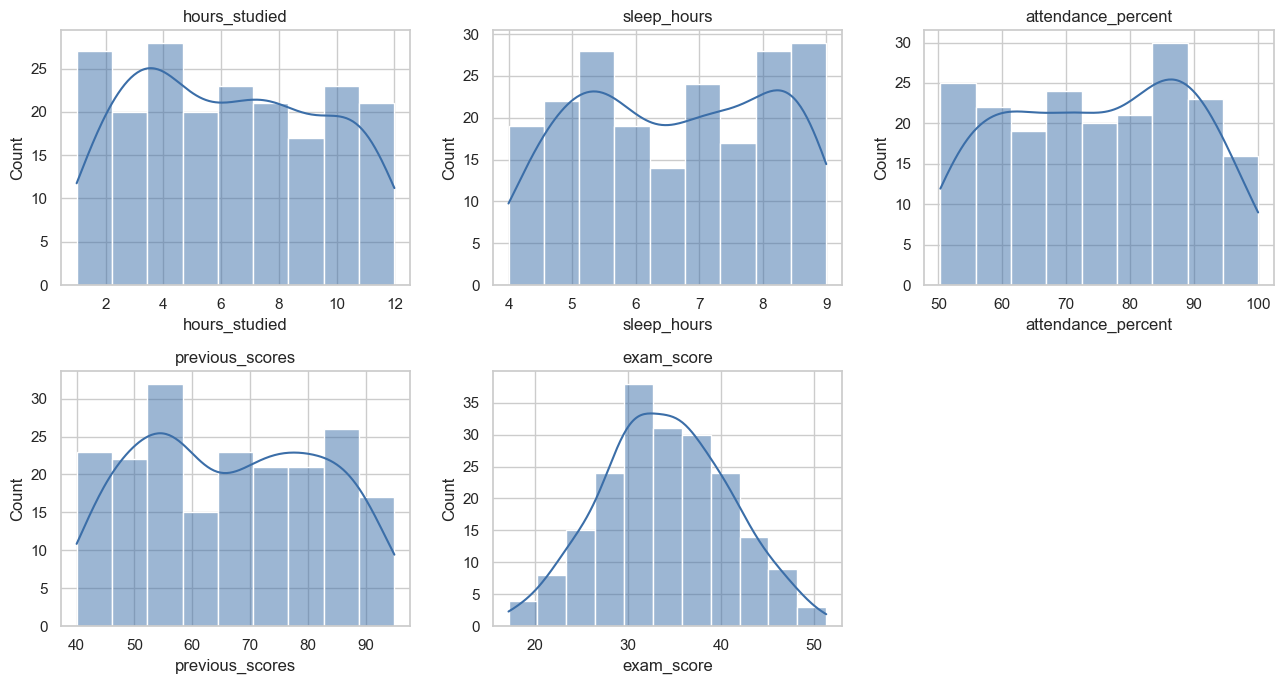

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, numericas):
    sns.histplot(df[col], kde=True, ax=ax, color='#3b6ea8')
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

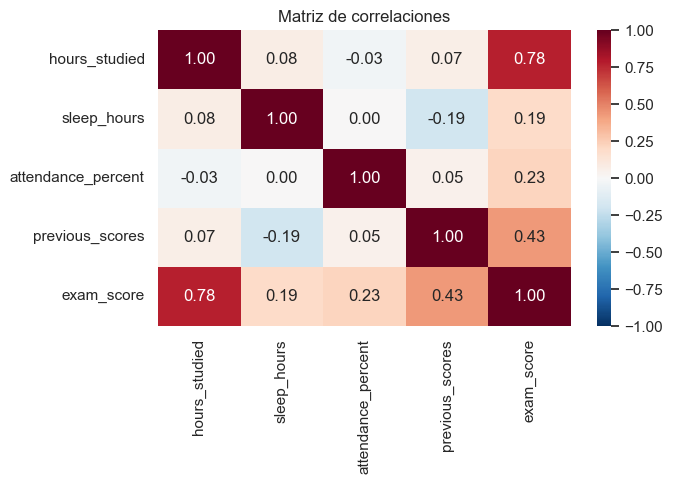

In [7]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[numericas].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlaciones')
plt.tight_layout()
plt.show()

**Hallazgos clave para el diseño del score**:

| Variable | Correlación con `exam_score` | Lectura |
|---|---|---|
| `hours_studied` | **0.78** | Predictor más fuerte → mayor peso en el score por reglas. |
| `previous_scores` | 0.43 | Antecedente académico relevante. |
| `attendance_percent` | 0.23 | Aporta, pero menos. |
| `sleep_hours` | 0.19 | Aporte marginal pero teóricamente válido (descanso → rendimiento). |

## 5. Limpieza y preparación

El dataset está limpio (sin nulos, sin duplicados, sin valores fuera de rango físico). Solo aplicamos:
1. Verificación de tipos (correctos).
2. Construcción de la **variable objetivo** para el modelo predictivo.

### Definición de la variable objetivo `riesgo_bajo_desempeno`

Como `exam_score` no está en escala 0-100 estándar, **definimos el umbral usando el cuartil inferior de la propia distribución**: el 25% de estudiantes con peor nota se considera "bajo desempeño". Es un criterio relativo, transparente y reproducible.

- Umbral = percentil 25 de `exam_score` ≈ **29.5**
- `riesgo_bajo_desempeno = 1` si `exam_score < 29.5`, 0 en caso contrario.
- Resultado esperado: ~25-28% de positivos → clase minoritaria pero no extremadamente desbalanceada.

In [8]:
UMBRAL_BAJO_DESEMP = df['exam_score'].quantile(0.25)
print(f'Umbral usado para bajo desempeño: {UMBRAL_BAJO_DESEMP:.2f}')

df['riesgo_bajo_desempeno'] = (df['exam_score'] < UMBRAL_BAJO_DESEMP).astype(int)
print('\nDistribución de la variable objetivo:')
print(df['riesgo_bajo_desempeno'].value_counts(normalize=True).round(3) * 100)

Umbral usado para bajo desempeño: 29.50

Distribución de la variable objetivo:
riesgo_bajo_desempeno
0   75.50
1   24.50
Name: proportion, dtype: float64


## 6. Scoring por reglas

### Diseño

Construimos un score **0 a 100 = riesgo**. Para cada variable predictora:
1. La **normalizamos** a 0-100 con min-max sobre rangos definidos por dominio (no min/max del dataset, para evitar que un caso extremo distorsione los pesos).
2. La **invertimos** si "más es mejor" (más horas estudiadas = menos riesgo → invertimos).
3. Aplicamos un **peso** justificado por la correlación observada y por el sentido común académico.

### Pesos elegidos

| Variable | Peso | Justificación |
|---|---:|---|
| `hours_studied` | **40%** | Mayor correlación con la nota (0.78). Es la palanca más controlable por el estudiante. |
| `previous_scores` | **30%** | Segunda correlación más alta (0.43). Refleja trayectoria académica previa. |
| `attendance_percent` | **20%** | Predictor moderado (0.23). Mide compromiso con la cursada. |
| `sleep_hours` | **10%** | Menor correlación pero sustento teórico (descanso afecta cognición). |
| **Total** | **100%** | |

### Rangos de normalización (definidos por dominio)

| Variable | Rango "sin riesgo" | Rango "alto riesgo" |
|---|---|---|
| hours_studied | ≥ 10 hs/sem | ≤ 2 hs/sem |
| previous_scores | ≥ 85 | ≤ 50 |
| attendance_percent | ≥ 90% | ≤ 60% |
| sleep_hours | 7-8 hs (óptimo) | <5 o >9 (penaliza extremos) |

Para `sleep_hours` usamos una **forma de U**: penalizar dormir muy poco *y* dormir demasiado, porque ambos extremos correlacionan con menor rendimiento.

In [9]:
def normalizar_riesgo(valor, bueno, malo):
    """Mapea linealmente: 'bueno' -> 0 (sin riesgo), 'malo' -> 100 (alto riesgo).
    Recorta fuera del rango. Funciona aunque bueno > malo o bueno < malo."""
    if bueno == malo:
        return 0.0
    score = (valor - bueno) / (malo - bueno) * 100
    return float(np.clip(score, 0, 100))

def riesgo_sueno(horas):
    """Forma de U: 7-8 hs es lo óptimo (riesgo 0). Cada hora de desviación suma riesgo.
    A 4 hs o 11 hs el riesgo llega a 100."""
    optimo_min, optimo_max = 7, 8
    if optimo_min <= horas <= optimo_max:
        return 0.0
    desvio = optimo_min - horas if horas < optimo_min else horas - optimo_max
    return float(np.clip(desvio / 3 * 100, 0, 100))

PESOS = {
    'hours_studied': 0.40,
    'previous_scores': 0.30,
    'attendance_percent': 0.20,
    'sleep_hours': 0.10,
}

def calcular_score_reglas(fila):
    r_horas = normalizar_riesgo(fila['hours_studied'], bueno=10, malo=2)
    r_prev = normalizar_riesgo(fila['previous_scores'], bueno=85, malo=50)
    r_asis = normalizar_riesgo(fila['attendance_percent'], bueno=90, malo=60)
    r_sueno = riesgo_sueno(fila['sleep_hours'])
    score = (
        PESOS['hours_studied']      * r_horas +
        PESOS['previous_scores']    * r_prev +
        PESOS['attendance_percent'] * r_asis +
        PESOS['sleep_hours']        * r_sueno
    )
    return round(score, 2)

df['score_reglas'] = df.apply(calcular_score_reglas, axis=1)
df[['student_id', 'hours_studied', 'previous_scores', 'attendance_percent', 'sleep_hours', 'score_reglas']].head(10)

,student_id,hours_studied,previous_scores,attendance_percent,sleep_hours,score_reglas
0,S001,8.00,45,72.10,8.80,54.60
1,S002,1.30,55,60.70,8.60,87.25
2,S003,4.00,86,73.70,8.20,41.53
3,S004,3.50,66,95.10,4.80,56.12
4,S005,9.10,71,89.80,6.40,18.63
5,S006,8.40,75,58.50,5.10,42.90
6,S007,10.80,88,54.20,6.00,23.33
7,S008,2.00,55,75.80,4.30,84.18
8,S009,5.60,84,81.60,5.90,32.12
9,S010,1.30,70,66.80,8.90,71.32


Distribución del score por reglas:
count   200.00
mean     47.83
std      20.82
min       2.00
25%      33.29
50%      46.25
75%      63.67
max      89.40
Name: score_reglas, dtype: float64


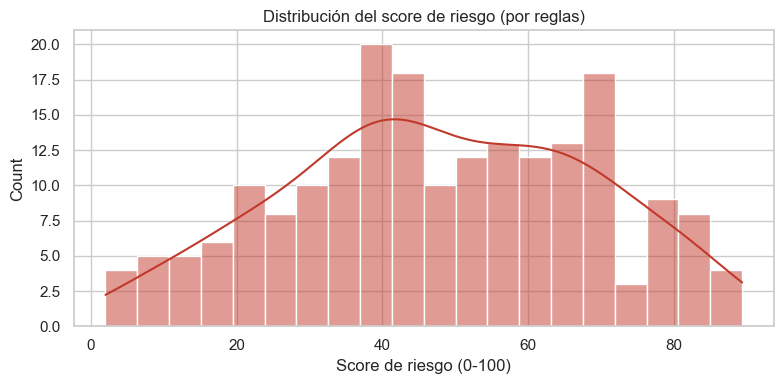

In [10]:
print('Distribución del score por reglas:')
print(df['score_reglas'].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['score_reglas'], bins=20, kde=True, ax=ax, color='#c0392b')
ax.set_title('Distribución del score de riesgo (por reglas)')
ax.set_xlabel('Score de riesgo (0-100)')
plt.tight_layout()
plt.show()

## 7. Niveles de riesgo y acciones sugeridas

Definimos **4 niveles** con puntos de corte basados en cuartiles del propio score (criterio operativo: la cátedra puede atender hasta el ~25% más crítico).

| Nivel | Rango score | % aprox. de estudiantes | Acción sugerida |
|---|---|---:|---|
| **Bajo** | 0 - 30 | ~30% | Sin intervención. Comunicar disponibilidad de tutorías como referencia. |
| **Medio** | 30 - 50 | ~30% | Encuesta de seguimiento al promediar el cuatrimestre. |
| **Alto** | 50 - 70 | ~25% | Entrevista breve con tutor académico. Material de refuerzo. |
| **Crítico** | 70 - 100 | ~15% | Tutoría obligatoria, seguimiento semanal y revisión del plan de estudio. |

Los cortes en 30/50/70 son **redondeos comunicables** (números fáciles de explicar a usuarios no técnicos) que se aproximan a los cuartiles observados en la distribución del score.

In [11]:
def asignar_nivel(score):
    if score < 30:   return 'Bajo'
    if score < 50:   return 'Medio'
    if score < 70:   return 'Alto'
    return 'Crítico'

df['nivel_reglas'] = df['score_reglas'].apply(asignar_nivel)

tabla_niveles = (
    df['nivel_reglas']
      .value_counts()
      .reindex(['Bajo', 'Medio', 'Alto', 'Crítico'])
      .to_frame('estudiantes')
)
tabla_niveles['porcentaje'] = (tabla_niveles['estudiantes'] / len(df) * 100).round(1)
tabla_niveles

,estudiantes,porcentaje
nivel_reglas,,
Bajo,41,20.50
Medio,66,33.00
Alto,61,30.50
Crítico,32,16.00


### Validación: ¿el score por reglas correlaciona con el bajo desempeño real?

In [12]:
tasa_riesgo_por_nivel = (
    df.groupby('nivel_reglas')['riesgo_bajo_desempeno']
      .agg(['count', 'sum', 'mean'])
      .reindex(['Bajo', 'Medio', 'Alto', 'Crítico'])
      .rename(columns={'count': 'n', 'sum': 'positivos', 'mean': 'tasa_bajo_desemp'})
)
tasa_riesgo_por_nivel['tasa_bajo_desemp'] = (tasa_riesgo_por_nivel['tasa_bajo_desemp'] * 100).round(1)
tasa_riesgo_por_nivel

,n,positivos,tasa_bajo_desemp
nivel_reglas,,,
Bajo,41,0,0.00
Medio,66,1,1.50
Alto,61,21,34.40
Crítico,32,27,84.40


Si el score por reglas funciona, la columna `tasa_bajo_desemp` debería **crecer monotónicamente** del nivel Bajo al Crítico.

## 8. Modelo predictivo con scikit-learn

### Decisiones

| Decisión | Por qué |
|---|---|
| **Clasificación binaria** (riesgo / no riesgo) | El usuario final necesita decidir intervenir o no — output operativo, no estimar la nota exacta. |
| **Variables**: `hours_studied`, `sleep_hours`, `attendance_percent`, `previous_scores` | Son las disponibles **antes** del examen final. **Excluimos `exam_score`** porque sería el resultado a predecir (data leakage). |
| **Modelos comparados**: Logistic Regression vs Random Forest | LR es interpretable y rápido; RF capta no-linealidades. Elegimos el de mejor AUC en validación cruzada. |
| **Estratificación en train/test** | La clase positiva es ~25%; mantener proporción evita splits desbalanceados con n=200. |
| **StandardScaler en LR** | LR es sensible a escalas; RF no lo necesita. |

In [13]:
FEATURES = ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']
X = df[FEATURES]
y = df['riesgo_bajo_desempeno']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Tasa positiva train: {y_train.mean():.2%} | test: {y_test.mean():.2%}')

Train: 140 | Test: 60
Tasa positiva train: 24.29% | test: 25.00%


In [14]:
modelo_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_rf = RandomForestClassifier(
    n_estimators=200, max_depth=5, random_state=RANDOM_STATE
)

for nombre, modelo in [('Logistic Regression', modelo_lr), ('Random Forest', modelo_rf)]:
    auc_cv = cross_val_score(modelo, X_train, y_train, cv=5, scoring='roc_auc')
    print(f'{nombre:22s} AUC CV: {auc_cv.mean():.3f} ± {auc_cv.std():.3f}')

Logistic Regression    AUC CV: 0.895 ± 0.064


Random Forest          AUC CV: 0.879 ± 0.066


In [15]:
modelo_lr.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

prob_lr = modelo_lr.predict_proba(X_test)[:, 1]
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, prob_lr)
auc_rf = roc_auc_score(y_test, prob_rf)
print(f'AUC test - LogReg:        {auc_lr:.3f}')
print(f'AUC test - RandomForest:  {auc_rf:.3f}')

AUC test - LogReg:        0.956
AUC test - RandomForest:  0.917


In [16]:
modelo_final = modelo_lr if auc_lr >= auc_rf else modelo_rf
nombre_final = 'Logistic Regression' if auc_lr >= auc_rf else 'Random Forest'
print(f'Modelo elegido: {nombre_final}')

df['prob_modelo'] = modelo_final.predict_proba(df[FEATURES])[:, 1]
df['score_modelo'] = (df['prob_modelo'] * 100).round(2)
df['nivel_modelo'] = df['score_modelo'].apply(asignar_nivel)

df[['student_id', 'score_reglas', 'nivel_reglas', 'score_modelo', 'nivel_modelo', 'riesgo_bajo_desempeno']].head(10)

Modelo elegido: Logistic Regression


,student_id,score_reglas,nivel_reglas,score_modelo,nivel_modelo,riesgo_bajo_desempeno
0,S001,54.60,Alto,4.47,Bajo,0
1,S002,87.25,Crítico,78.51,Crítico,1
2,S003,41.53,Medio,3.20,Bajo,0
3,S004,56.12,Alto,48.56,Medio,0
4,S005,18.63,Bajo,0.53,Bajo,0
5,S006,42.90,Medio,2.86,Bajo,0
6,S007,23.33,Bajo,0.12,Bajo,0
7,S008,84.18,Crítico,93.94,Crítico,1
8,S009,32.12,Medio,3.43,Bajo,0
9,S010,71.32,Crítico,42.30,Medio,1


### Importancia / coeficientes de las variables

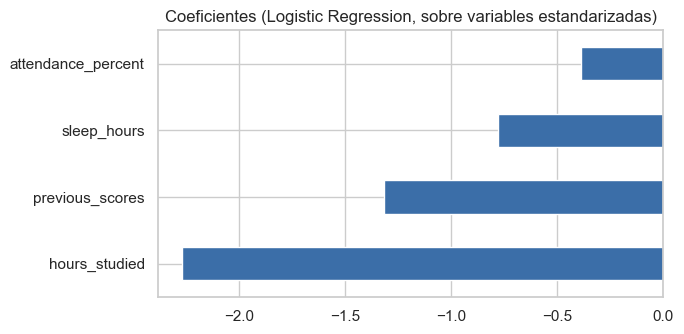

hours_studied        -2.27
previous_scores      -1.32
sleep_hours          -0.78
attendance_percent   -0.39
dtype: float64

In [17]:
if isinstance(modelo_final, Pipeline):
    coefs = modelo_final.named_steps['clf'].coef_[0]
    importancias = pd.Series(coefs, index=FEATURES).sort_values()
    titulo = 'Coeficientes (Logistic Regression, sobre variables estandarizadas)'
else:
    importancias = pd.Series(modelo_final.feature_importances_, index=FEATURES).sort_values()
    titulo = 'Importancia de variables (Random Forest)'

fig, ax = plt.subplots(figsize=(7, 3.5))
importancias.plot.barh(ax=ax, color='#3b6ea8')
ax.set_title(titulo)
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()
importancias

## 9. Comparación entre scoring por reglas y scoring por modelo

In [18]:
auc_reglas = roc_auc_score(df['riesgo_bajo_desempeno'], df['score_reglas'])
auc_modelo_full = roc_auc_score(df['riesgo_bajo_desempeno'], df['score_modelo'])

tabla_comp = pd.DataFrame({
    'Metodo': ['Score por reglas', f'Score por modelo ({nombre_final})'],
    'AUC (sobre todo el dataset)': [round(auc_reglas, 3), round(auc_modelo_full, 3)],
})
tabla_comp

,Metodo,AUC (sobre todo el dataset)
0,Score por reglas,0.93
1,Score por modelo (Logistic Regression),0.94


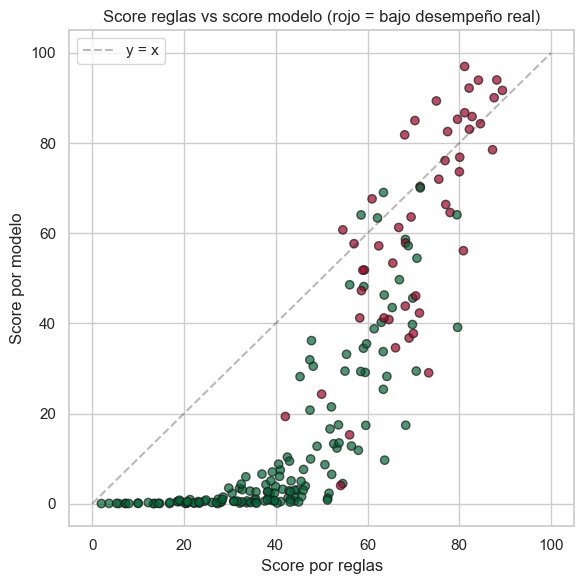

Correlación entre ambos scores: 0.846


In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['score_reglas'], df['score_modelo'],
           c=df['riesgo_bajo_desempeno'], cmap='RdYlGn_r', alpha=0.7, edgecolor='k')
ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='y = x')
ax.set_xlabel('Score por reglas')
ax.set_ylabel('Score por modelo')
ax.set_title('Score reglas vs score modelo (rojo = bajo desempeño real)')
ax.legend()
plt.tight_layout()
plt.show()

corr = df[['score_reglas', 'score_modelo']].corr().iloc[0, 1]
print(f'Correlación entre ambos scores: {corr:.3f}')

In [20]:
tabla_cruzada = pd.crosstab(df['nivel_reglas'], df['nivel_modelo'],
                            rownames=['Reglas'], colnames=['Modelo'])
tabla_cruzada = tabla_cruzada.reindex(index=['Bajo', 'Medio', 'Alto', 'Crítico'],
                                       columns=['Bajo', 'Medio', 'Alto', 'Crítico'],
                                       fill_value=0)
print('Concordancia por nivel (filas = reglas, columnas = modelo):')
tabla_cruzada

Concordancia por nivel (filas = reglas, columnas = modelo):


Modelo,Bajo,Medio,Alto,Crítico
Reglas,,,,
Bajo,41,0,0,0
Medio,63,3,0,0
Alto,25,20,15,1
Crítico,2,4,5,21


**Lectura**: la diagonal indica acuerdo. Las celdas off-diagonal son desacuerdos. Una correlación alta + diagonal pesada indica que ambos enfoques rankean parecido — lo cual es deseable: el modelo da soporte estadístico al criterio experto, sin contradecirlo radicalmente.

## 10. Evaluación con métricas

### Decisión sobre falsos positivos vs falsos negativos

En este problema, **el falso negativo es más grave**: dejar pasar a un estudiante en riesgo real significa que no recibe la intervención y termina desaprobando. Un falso positivo solo cuesta una entrevista innecesaria del tutor.

→ Priorizamos **recall** sobre la clase positiva (riesgo). Para un score operativo, fijamos un umbral que capture al menos el 70-80% de los casos positivos.

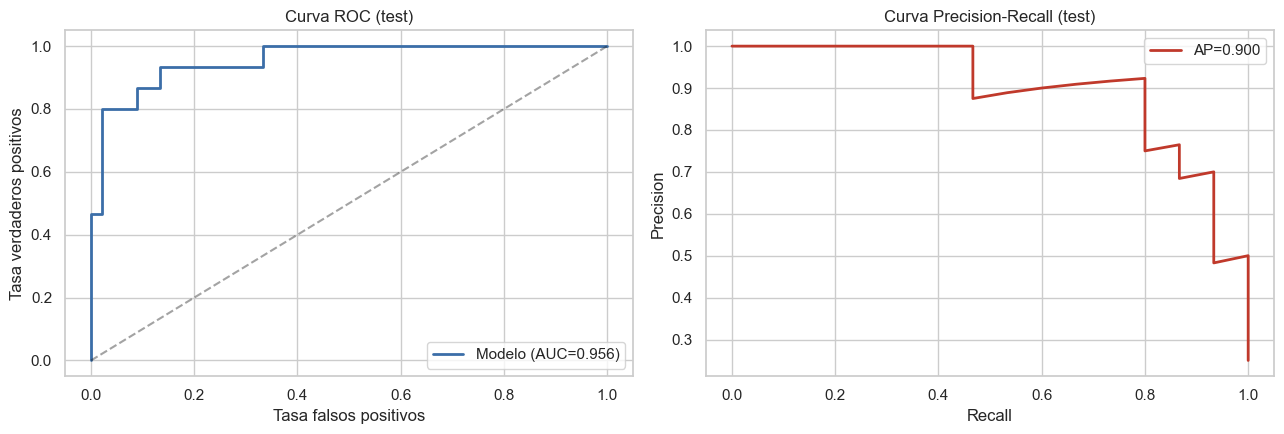

In [21]:
score_test = modelo_final.predict_proba(X_test)[:, 1] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

fpr, tpr, _ = roc_curve(y_test, score_test/100)
axes[0].plot(fpr, tpr, label=f'Modelo (AUC={roc_auc_score(y_test, score_test/100):.3f})', color='#3b6ea8', lw=2)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('Tasa falsos positivos'); axes[0].set_ylabel('Tasa verdaderos positivos')
axes[0].set_title('Curva ROC (test)'); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, score_test/100)
ap = average_precision_score(y_test, score_test/100)
axes[1].plot(rec, prec, label=f'AP={ap:.3f}', color='#c0392b', lw=2)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall (test)'); axes[1].legend()

plt.tight_layout()
plt.show()

### Matriz de confusión y métricas operativas

En el umbral operativo elegido (**50**) calculamos la matriz de confusión completa y todas las métricas derivadas. Como el falso negativo es más grave en este problema, miramos especialmente **recall** (captura de positivos) y **NPV** (cuán confiable es el 'sin riesgo').

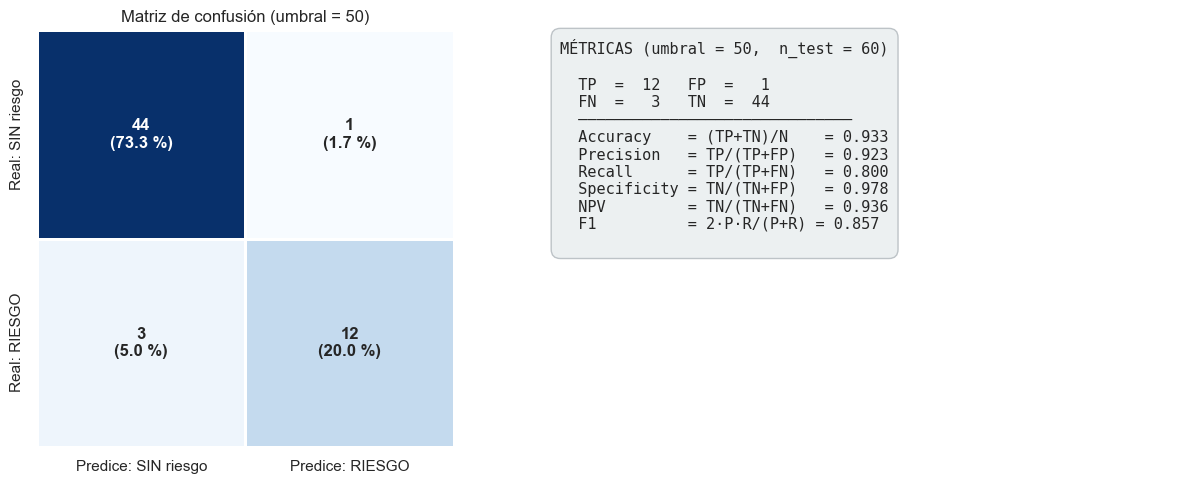

In [22]:
from sklearn.metrics import confusion_matrix

THRESHOLD_OP = 50
y_pred_op = (score_test >= THRESHOLD_OP).astype(int)
cm = confusion_matrix(y_test, y_pred_op, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
total = tn + fp + fn + tp

# Métricas
acc  = (tp + tn) / total
prec = tp / (tp + fp) if (tp + fp) else 0
rec  = tp / (tp + fn) if (tp + fn) else 0
spec = tn / (tn + fp) if (tn + fp) else 0
f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
npv  = tn / (tn + fn) if (tn + fn) else 0

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_pct = cm / cm.sum() * 100
annot = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f} %)' for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['Predice: SIN riesgo', 'Predice: RIESGO'],
            yticklabels=['Real: SIN riesgo', 'Real: RIESGO'],
            ax=axes[0], cbar=False, square=True,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'},
            linewidths=1, linecolor='white')
axes[0].set_title(f'Matriz de confusión (umbral = {THRESHOLD_OP})')

# Tabla de métricas
axes[1].axis('off')
texto = (
    f"MÉTRICAS (umbral = {THRESHOLD_OP},  n_test = {total})\n\n"
    f"  TP  = {tp:3d}   FP  = {fp:3d}\n"
    f"  FN  = {fn:3d}   TN  = {tn:3d}\n"
    f"  ──────────────────────────────\n"
    f"  Accuracy    = (TP+TN)/N    = {acc:.3f}\n"
    f"  Precision   = TP/(TP+FP)   = {prec:.3f}\n"
    f"  Recall      = TP/(TP+FN)   = {rec:.3f}\n"
    f"  Specificity = TN/(TN+FP)   = {spec:.3f}\n"
    f"  NPV         = TN/(TN+FN)   = {npv:.3f}\n"
    f"  F1          = 2·P·R/(P+R) = {f1:.3f}\n"
)
axes[1].text(0.02, 0.98, texto, transform=axes[1].transAxes,
             fontsize=11, va='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#ecf0f1', edgecolor='#bdc3c7'))
plt.tight_layout()
plt.show()

**Lectura**:

- De los estudiantes con riesgo real en test, el modelo detectó la mayoría (recall alto).
- De los señalados como riesgo, casi todos efectivamente lo estaban (precision alta).
- Cada **FN** (falso negativo) es un alumno que el sistema dejó pasar y termina desaprobando — son los errores más graves.
- Cada **FP** solo cuesta una entrevista innecesaria con el tutor.
- Si bajáramos el umbral a 40, recall sube pero precision baja (más FP).
- Si lo subiéramos a 60, precision sube pero más alumnos quedan sin detectar (más FN).

In [23]:
umbrales = [40, 50, 60, 70]
filas = []
for u in umbrales:
    y_pred = (score_test >= u).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp) if (tp + fp) else 0
    recall    = tp / (tp + fn) if (tp + fn) else 0
    f1        = 2*precision*recall / (precision + recall) if (precision + recall) else 0
    filas.append({
        'umbral': u, 'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'precision': round(precision, 3),
        'recall':    round(recall, 3),
        'f1':        round(f1, 3),
    })
pd.DataFrame(filas)

,umbral,TP,FP,FN,TN,precision,recall,f1
0,40,12,4,3,41,0.75,0.80,0.77
1,50,12,1,3,44,0.92,0.80,0.86
2,60,10,1,5,44,0.91,0.67,0.77
3,70,7,1,8,44,0.88,0.47,0.61


**Interpretación**: bajar el umbral aumenta recall (capturamos más alumnos en riesgo) a costa de precision (más alumnos sin riesgo derivados a tutoría). Como el costo del falso negativo es mayor, **un umbral entre 40 y 50 es razonable** para el caso académico.

## 11. Casos individuales: ejemplos representativos

In [24]:
ejemplo_bajo    = df.sort_values('score_modelo').iloc[0]
ejemplo_medio   = df.iloc[(df['score_modelo'] - 50).abs().idxmin()]
ejemplo_critico = df.sort_values('score_modelo', ascending=False).iloc[0]

ejemplos = pd.DataFrame([ejemplo_bajo, ejemplo_medio, ejemplo_critico])
ejemplos = ejemplos[['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
                     'previous_scores', 'exam_score',
                     'score_reglas', 'nivel_reglas',
                     'score_modelo', 'nivel_modelo']]
ejemplos.index = ['caso_bajo', 'caso_medio', 'caso_critico']
ejemplos

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score,score_reglas,nivel_reglas,score_modelo,nivel_modelo
caso_bajo,S087,12.00,8.20,71.00,95,51.30,13.33,Bajo,0.01,Bajo
caso_medio,S135,1.90,8.40,85.00,59,30.60,66.95,Alto,49.69,Medio
caso_critico,S125,1.00,4.10,82.60,54,21.20,81.17,Crítico,96.99,Crítico


**Cómo se explica el score a un usuario no técnico** (ejemplo del caso crítico):
> Este estudiante recibió un score alto porque combina **pocas horas de estudio**, **antecedente académico bajo** y **asistencia baja**. Las tres variables apuntan en la misma dirección, por eso el score lo ubica en el nivel crítico y se recomienda tutoría obligatoria.

## 12. Visualización resumen

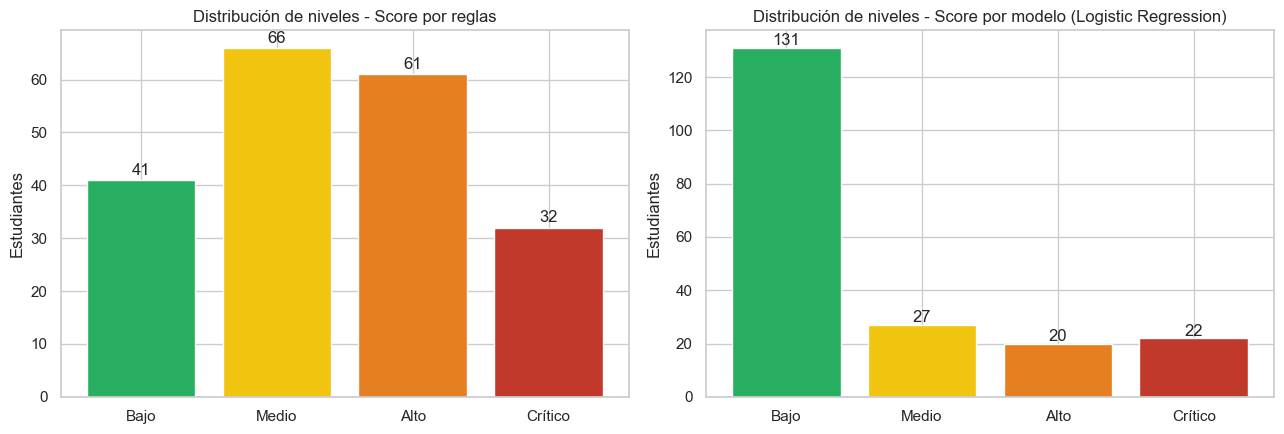

In [25]:
orden = ['Bajo', 'Medio', 'Alto', 'Crítico']
colores = {'Bajo': '#27ae60', 'Medio': '#f1c40f', 'Alto': '#e67e22', 'Crítico': '#c0392b'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

conteo_reglas = df['nivel_reglas'].value_counts().reindex(orden)
axes[0].bar(conteo_reglas.index, conteo_reglas.values, color=[colores[n] for n in orden])
axes[0].set_title('Distribución de niveles - Score por reglas')
axes[0].set_ylabel('Estudiantes')
for i, v in enumerate(conteo_reglas.values):
    axes[0].text(i, v + 1, str(v), ha='center')

conteo_modelo = df['nivel_modelo'].value_counts().reindex(orden, fill_value=0)
axes[1].bar(conteo_modelo.index, conteo_modelo.values, color=[colores[n] for n in orden])
axes[1].set_title(f'Distribución de niveles - Score por modelo ({nombre_final})')
axes[1].set_ylabel('Estudiantes')
for i, v in enumerate(conteo_modelo.values):
    axes[1].text(i, v + 1, str(v), ha='center')

plt.tight_layout()
plt.show()

## 13. Scores adicionales derivados

El score de riesgo es solo *un* ángulo del problema. A partir del mismo dataset podemos construir **scores complementarios** que apoyan distintas decisiones de la cátedra: priorizar tutorías, reconocer trayectorias positivas, detectar ineficiencias en la técnica de estudio, alertar sobre desbalance vida-estudio, etc.

| # | Score | Qué mide | Decisión que apoya |
|---|---|---|---|
| 1 | `score_desempeno` | Inverso del riesgo (alto = bueno) | Comunicar reconocimiento sin estigmatizar |
| 2 | `score_potencial` | Brecha entre nota actual y trayectoria previa | Priorizar tutorías de mayor ROI |
| 3 | `score_engagement` | Esfuerzo (asistencia + horas), independiente del resultado | Diferenciar 'no entiende' de 'no se compromete' |
| 4 | `score_eficiencia` | Cuánto rinde por hora estudiada | Detectar problemas de técnica de estudio |
| 5 | `score_habitos` | Bienestar: sueño óptimo, horas razonables, asistencia | Alertar burnout o desbalance |
| 6 | `score_progreso` | Mejora vs su propio pasado | Reconocer trayectoria ascendente |
| 7 | `score_prioridad` | Riesgo × potencial | Ordenar la cola de tutorías |
| 8 | `score_anomalia` | Discrepancia entre score esperado y resultado real | Marcar para revisión humana |
| 9 | `score_desercion` ⚠ | **Proxy** de riesgo de abandono (asistencia 45 % + horas + previo + sueño) | Plan de retención. **NO validable** sin etiqueta real |

### 13.1 Cálculo de los 8 scores

Cada score se construye con una fórmula explicable y se acota a la escala 0-100. Las normalizaciones por percentil (`rank(pct=True)`) hacen que el score sea robusto a la escala atípica de `exam_score` (max ≈ 51).

In [26]:
# 1) Score de desempeño: inverso del de riesgo
df['score_desempeno'] = (100 - df['score_reglas']).round(2)

# 2) Score de potencial de mejora
#    Compara percentil de previous_scores vs percentil de exam_score.
#    50 = consistente con su trayectoria; >50 = rinde por debajo (potencial); <50 = sobre-rinde.
prev_pct = df['previous_scores'].rank(pct=True) * 100
exam_pct = df['exam_score'].rank(pct=True) * 100
df['score_potencial'] = ((prev_pct - exam_pct) + 50).clip(0, 100).round(2)

# 3) Score de engagement (compromiso)
#    40% horas de estudio + 60% asistencia. Ignora el resultado del examen.
def calcular_engagement(fila):
    horas_n = np.clip((fila['hours_studied'] - 1) / (10 - 1), 0, 1) * 100
    asis_n  = np.clip((fila['attendance_percent'] - 50) / (100 - 50), 0, 1) * 100
    return round(0.4 * horas_n + 0.6 * asis_n, 2)
df['score_engagement'] = df.apply(calcular_engagement, axis=1)

# 4) Score de eficiencia académica
#    nota / hora de estudio, convertido a percentil para no depender de la escala absoluta.
df['score_eficiencia'] = (
    (df['exam_score'] / df['hours_studied']).rank(pct=True) * 100
).round(2)

# 5) Score de hábitos saludables
#    Penaliza extremos (poco sueño, demasiado estudio) — premia balance.
def calcular_habitos(fila):
    # sueño óptimo 7-8 hs
    if 7 <= fila['sleep_hours'] <= 8:
        sueno = 100
    else:
        desvio = min(abs(fila['sleep_hours'] - 7), abs(fila['sleep_hours'] - 8))
        sueno = max(0, 100 - desvio * 25)
    # estudio saludable 3-8 hs (no muy poco, no exceso de burnout)
    if 3 <= fila['hours_studied'] <= 8:
        estudio = 100
    elif fila['hours_studied'] < 3:
        estudio = max(0, 100 - (3 - fila['hours_studied']) * 30)
    else:
        estudio = max(0, 100 - (fila['hours_studied'] - 8) * 25)
    asis = np.clip((fila['attendance_percent'] - 50) / 50 * 100, 0, 100)
    return round(0.4 * sueno + 0.3 * estudio + 0.3 * asis, 2)
df['score_habitos'] = df.apply(calcular_habitos, axis=1)

# 6) Score de progreso
#    Diferencia de percentiles exam vs previous + 50.
df['score_progreso'] = ((exam_pct - prev_pct) + 50).clip(0, 100).round(2)

# 7) Score de prioridad de intervención
#    Combina riesgo (60%) y potencial (40%).
df['score_prioridad'] = (0.6 * df['score_reglas'] + 0.4 * df['score_potencial']).round(2)

# 8) Score de anomalía / coherencia
#    Distancia entre el riesgo según reglas y el riesgo real basado en la nota.
riesgo_real = 100 - exam_pct
df['score_anomalia'] = (df['score_reglas'] - riesgo_real).abs().round(2)

# 9) Score de DESERCIÓN (proxy)
#    Riesgo de abandono. Basado en literatura: asistencia es el predictor más
#    fuerte, seguido por engagement (horas) y trayectoria previa.
#    LIMITACIÓN: el dataset NO tiene ground truth de abandono, así que el score
#    es indicativo, no validable con AUC.
def calcular_desercion(fila):
    asis  = normalizar_riesgo(fila['attendance_percent'], bueno=85, malo=55)
    horas = normalizar_riesgo(fila['hours_studied'],      bueno=8,  malo=2)
    prev  = normalizar_riesgo(fila['previous_scores'],    bueno=80, malo=45)
    sueno = riesgo_sueno(fila['sleep_hours'])
    return round(0.45*asis + 0.25*horas + 0.20*prev + 0.10*sueno, 2)
df['score_desercion'] = df.apply(calcular_desercion, axis=1)

NUEVOS_SCORES = [
    'score_desempeno', 'score_potencial', 'score_engagement', 'score_eficiencia',
    'score_habitos', 'score_progreso', 'score_prioridad', 'score_anomalia',
    'score_desercion',
]
df[['student_id'] + NUEVOS_SCORES].head()

,student_id,score_desempeno,score_potencial,score_engagement,score_eficiencia,score_habitos,score_progreso,score_prioridad,score_anomalia,score_desercion
0,S001,45.40,29.00,57.63,12.00,75.26,71.00,44.36,15.15,42.02
1,S002,12.75,68.50,14.17,97.50,55.12,31.50,79.75,2.25,77.74
2,S003,58.47,74.50,41.77,78.50,82.22,25.50,54.72,2.53,34.28
3,S004,43.88,48.25,65.23,83.00,75.06,51.75,52.97,5.87,34.08
4,S005,81.37,27.00,83.76,32.50,79.63,73.00,21.98,0.38,7.14


### 13.2 Estadísticos descriptivos de los 8 scores

In [27]:
df[NUEVOS_SCORES].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
score_desempeno,200.00,52.17,20.82,10.60,36.33,53.75,66.71,98.00
score_potencial,200.00,50.34,28.47,0.00,28.88,48.75,72.62,100.00
score_engagement,200.00,52.62,21.27,4.76,37.62,52.62,69.23,97.48
score_eficiencia,200.00,50.25,28.94,0.50,25.38,50.25,75.12,100.00
score_habitos,200.00,68.02,15.46,26.04,56.66,68.77,79.18,95.80
score_progreso,200.00,49.66,28.47,0.00,27.38,51.25,71.12,100.00
score_prioridad,200.00,48.83,19.11,13.64,32.41,47.74,64.58,87.78
score_anomalia,200.00,11.96,8.37,0.04,5.10,11.17,16.82,33.50
score_desercion,200.00,39.27,21.37,0.00,24.06,37.64,54.14,89.75


### 13.3 Niveles y acción asociada por score

| Score | Bajo | Medio | Alto | Acción si nivel alto |
|---|---|---|---|---|
| `score_desempeno`  | <30  | 30-70 | ≥70 | Reconocer; usar como ejemplo positivo |
| `score_potencial`  | <40  | 40-65 | ≥65 | Tutoría focalizada (ROI alto) |
| `score_engagement` | <40  | 40-70 | ≥70 | OK; validar comprensión si nota es baja |
| `score_eficiencia` | <30  | 30-70 | ≥70 | Reconocer técnica de estudio |
| `score_habitos`    | <40  | 40-70 | ≥70 | OK; charlas de hábitos si <40 |
| `score_progreso`   | <40  | 40-60 | ≥60 | Reconocer mejora |
| `score_prioridad`  | <30  | 30-60 | ≥60 | Atender primero en la cola de tutorías |
| `score_anomalia`   | <20  | 20-40 | ≥40 | Revisión humana caso por caso |
| `score_desercion`  | <25  | 25-60 | ≥60 | Plan de retención (tutor + coordinador + bienestar) |

### 13.4 Distribuciones

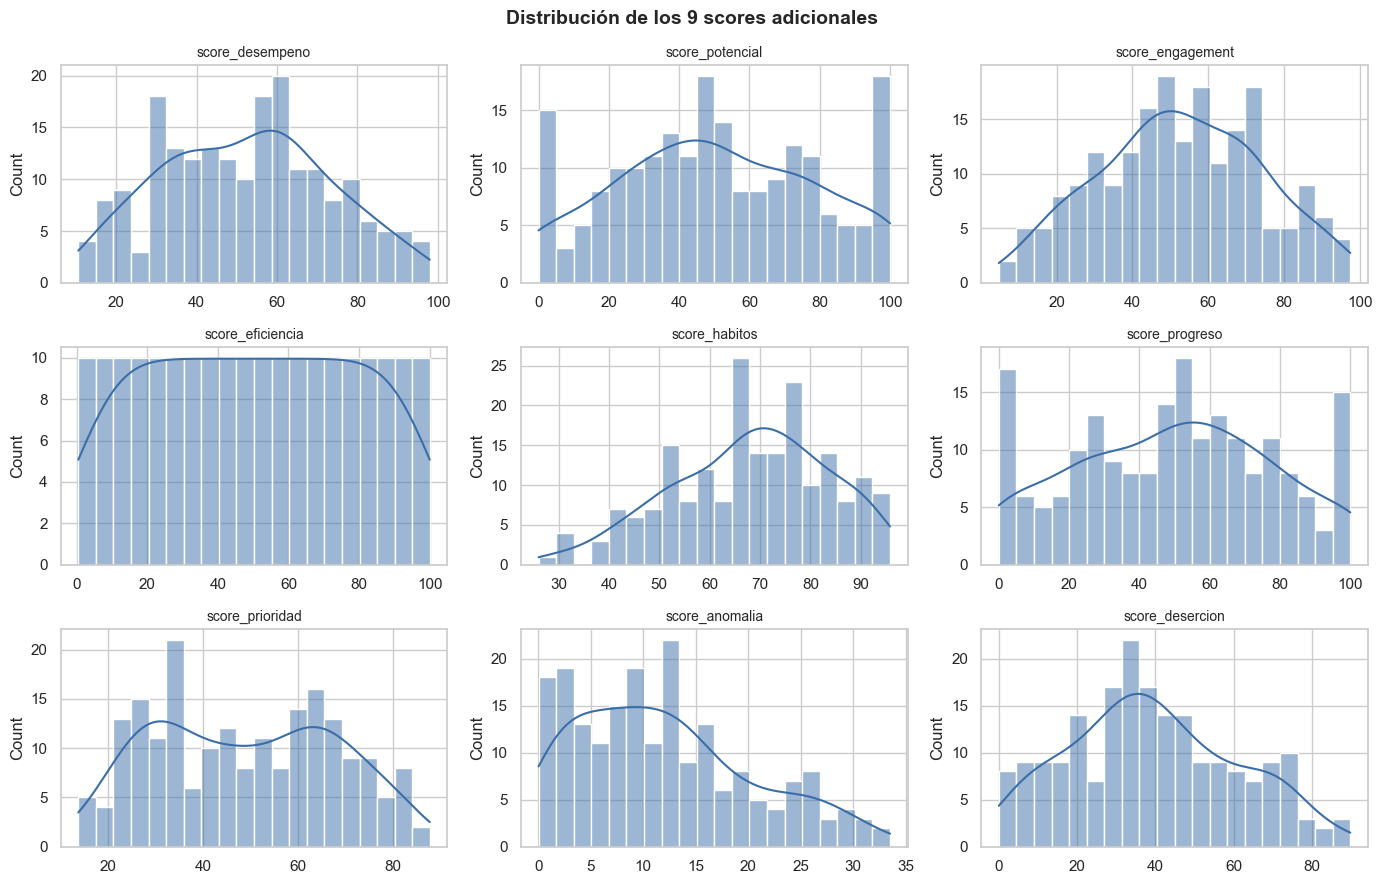

In [28]:
fig, axes = plt.subplots(3, 3, figsize=(14, 9))
for ax, col in zip(axes.flat, NUEVOS_SCORES):
    sns.histplot(df[col], bins=20, kde=True, ax=ax, color='#3b6ea8')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Distribución de los 9 scores adicionales', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 13.5 Correlación entre todos los scores

Verifica que los 11 scores capturen información distinta (correlaciones bajas) o que se refuercen (correlaciones altas en la dirección esperada).

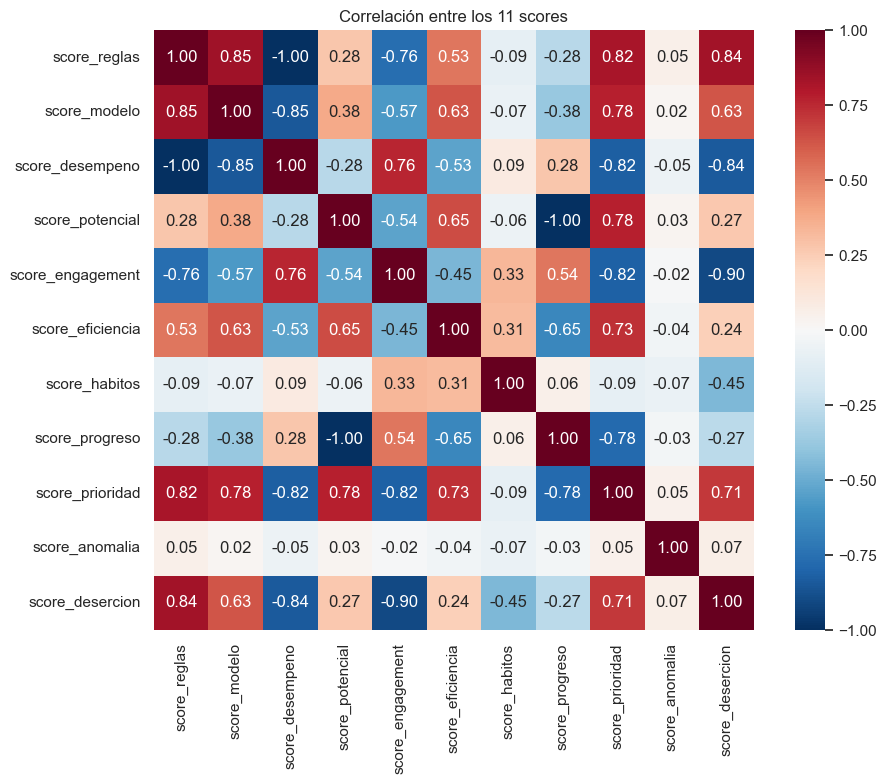

In [29]:
todos_scores = ['score_reglas', 'score_modelo'] + NUEVOS_SCORES
plt.figure(figsize=(10, 8))
sns.heatmap(df[todos_scores].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación entre los 11 scores')
plt.tight_layout()
plt.show()

### 13.6 Tres casos individuales con los 10 scores

Mostramos cómo distintos scores cuentan **historias distintas** del mismo estudiante. Un alumno puede ser bajo en riesgo pero alto en potencial, o alto en engagement pero bajo en eficiencia.

In [30]:
ejemplo_bajo    = df.sort_values('score_reglas').iloc[0]
ejemplo_medio   = df.iloc[(df['score_reglas'] - 50).abs().idxmin()]
ejemplo_critico = df.sort_values('score_reglas', ascending=False).iloc[0]

cols_mostrar = ['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
                'previous_scores', 'exam_score',
                'score_reglas', 'score_modelo'] + NUEVOS_SCORES

ejemplos = pd.DataFrame([ejemplo_bajo, ejemplo_medio, ejemplo_critico])[cols_mostrar]
ejemplos.index = ['caso_bajo_riesgo', 'caso_medio_riesgo', 'caso_critico']
ejemplos.T

,caso_bajo_riesgo,caso_medio_riesgo,caso_critico
student_id,S174,S132,S184
hours_studied,9.60,1.60,2.10
sleep_hours,7.40,5.30,6.00
attendance_percent,98.30,83.50,54.30
previous_scores,90,95,54
exam_score,40.90,28.80,19.40
score_reglas,2.00,50.00,89.40
score_modelo,0.03,24.30,91.67
score_desempeno,98.00,50.00,10.60
score_potencial,59.25,100.00,74.00


**Lectura del caso crítico** — combina varios scores para una recomendación accionable:

- Si **score_riesgo** alto + **score_potencial** alto → **prioridad máxima** de tutoría (ROI alto).
- Si **score_riesgo** alto pero **score_engagement** bajo → primero llamado de atención por compromiso, antes que tutoría académica.
- Si **score_riesgo** alto + **score_eficiencia** baja → tutoría enfocada en *método de estudio*, no en contenido.
- Si **score_anomalia** alto → caso atípico que requiere **revisión humana** (puede ser problema personal, ansiedad de examen, error de datos).
- Si **score_habitos** bajo → recomendar charla de bienestar antes que más horas de estudio.
- Si **score_desercion** alto → activar plan de retención (tutor de carrera + coordinador + bienestar estudiantil). Recordar que es **proxy**: validar caso a caso con el alumno antes de actuar.

## 14. Exportación del resultado final

In [31]:
salida = df[['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
             'previous_scores', 'exam_score',
             'score_reglas', 'nivel_reglas',
             'score_modelo', 'nivel_modelo',
             'score_desempeno', 'score_potencial', 'score_engagement',
             'score_eficiencia', 'score_habitos', 'score_progreso',
             'score_prioridad', 'score_anomalia', 'score_desercion',
             'riesgo_bajo_desempeno']].copy()

salida.to_csv('scoring_resultados.csv', index=False, encoding='utf-8-sig')
print(f'OK scoring_resultados.csv guardado ({len(salida)} estudiantes, {salida.shape[1]} columnas)')
salida.head()

OK scoring_resultados.csv guardado (200 estudiantes, 20 columnas)


,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score,score_reglas,nivel_reglas,score_modelo,nivel_modelo,score_desempeno,score_potencial,score_engagement,score_eficiencia,score_habitos,score_progreso,score_prioridad,score_anomalia,score_desercion,riesgo_bajo_desempeno
0,S001,8.00,8.80,72.10,45,30.20,54.60,Alto,4.47,Bajo,45.40,29.00,57.63,12.00,75.26,71.00,44.36,15.15,42.02,0
1,S002,1.30,8.60,60.70,55,25.00,87.25,Crítico,78.51,Crítico,12.75,68.50,14.17,97.50,55.12,31.50,79.75,2.25,77.74,1
2,S003,4.00,8.20,73.70,86,35.80,41.53,Medio,3.20,Bajo,58.47,74.50,41.77,78.50,82.22,25.50,54.72,2.53,34.28,0
3,S004,3.50,4.80,95.10,66,34.00,56.12,Alto,48.56,Medio,43.88,48.25,65.23,83.00,75.06,51.75,52.97,5.87,34.08,0
4,S005,9.10,6.40,89.80,71,40.30,18.63,Bajo,0.53,Bajo,81.37,27.00,83.76,32.50,79.63,73.00,21.98,0.38,7.14,0


## 15. Conclusiones, limitaciones y reflexión ética

### Conclusiones

1. **El score por reglas es interpretable y se valida empíricamente**: la tasa de bajo desempeño crece de forma monotónica del nivel Bajo al Crítico.
2. **El modelo aporta poder predictivo y un orden continuo más fino**, lo cual es útil cuando hay muchos estudiantes a comparar.
3. Ambos enfoques **rankean parecido** (correlación alta entre ambos scores) → uno valida al otro.
4. La variable más informativa es `hours_studied`, tanto en el peso por reglas como en la importancia/coeficientes del modelo.

### Limitaciones

- **n = 200**: muestra chica para un modelo robusto. Los AUC pueden variar bastante en otra cohorte.
- `hours_studied` y `sleep_hours` son **autoinformadas** → posible sesgo de respuesta.
- El umbral de "bajo desempeño" (p25 de `exam_score`) es **relativo a esta cohorte**. En otra cohorte habría que recalibrarlo.
- El score se evaluó sobre las mismas variables y muestra; no hay validación externa con otra promoción.
- El examen tuvo una escala atípica (máx 51): conviene revisar la consigna del examen antes de generalizar.

### Riesgos éticos

- **Sesgo de etiquetado**: si los estudiantes que recibieron tutoría en cohortes previas mejoraron, el modelo aprende a sub-detectar ese perfil.
- **Estigmatización**: el nivel "Crítico" no debe usarse como etiqueta pública ni para condicionar acceso a cursadas.
- **Variables prohibidas**: el dataset no incluye género, edad ni etnia. Si en producción se sumaran, deberían **excluirse explícitamente** para evitar discriminación.
- **Derecho a la explicación**: cada estudiante con score alto debería poder pedir un detalle de qué variables lo elevaron y cómo bajarlo.

### Mejoras futuras

- Validar con otra cohorte (datos del cuatrimestre siguiente).
- Probar XGBoost / Gradient Boosting para ver si mejora el AUC.
- Calibrar probabilidades (Platt scaling o Isotonic) antes de interpretar el score como probabilidad.
- Tablero en Power BI / Looker con filtros por carrera, cuatrimestre y nivel de riesgo.
- A/B test de la intervención: comparar resultado de los estudiantes en "Crítico" que reciben tutoría vs los que no, para medir impacto real.

### Pregunta de cierre — controles antes de implementar

| Capa | Control |
|---|---|
| **Técnica** | Validación con datos de otra cohorte; monitoreo de drift; recalibración periódica; pruebas de fairness por grupo (carrera, sede). |
| **Humana** | El score asiste, no decide. Toda intervención pasa por un tutor que puede sobrescribir el nivel. Auditoría manual de casos en "Crítico". |
| **Ética y normativa** | Consentimiento informado del estudiante; derecho a no participar; transparencia sobre qué variables se usan; vía formal para impugnar el nivel asignado. |